### Example 7 for the usage of Rela²x.
### See README.md for more information.

- ¹H and ¹³C nuclei, and a ²H nucleus.

- Residual dipolar and quadrupolar couplings, alongside the Zeeman interaction, the J-coupling, and the dipole-dipole and quadrupolar relaxation mechanisms.

- The coherent counterparts of the anisotropic relaxation mechanisms.

Import Rela²x.

In [1]:
from rela2x import *

Define the spin system.

In [2]:
spin_system = ['1H', '13C']

Define the coherent interactions. The residual dipolar coupling takes a coupling matrix, exactly as the J-coupling does.

In [3]:
coh_intrs = {'Z':   [1, 1],
             'J':   [[0, 1],
                     [0, 0]],
             'RDC': [[0, 1],
                     [0, 0]]}

Compute $H$ and create a HamiltonianSuperoperator object.

In [4]:
H = hamiltonian_superoperator(spin_system, coh_intrs)

################################################################################
                         Hamiltonian superoperator (H)                          
################################################################################

Computing H for the coherent interactions...
H computed in 0.01 seconds.

Changing basis...
Basis changed in 0.03 seconds.

Final clean-ups...
Done in 0.06 seconds.



Both couplings reduce to their longitudinal terms for a heteronuclear pair, so they enter the same matrix elements. Only the sum $J + D$ is visible, which is why a heteronuclear doublet splits by it.

In [5]:
H.frequency('111', '111*210')

2*pi*D_{12} + 2*pi*J_{12}

Repeat for a homonuclear pair, whose flip-flop terms survive the secular approximation. They enter with weight $+1$ for the J-coupling but $-1/2$ for the residual dipolar coupling, so the two couplings are no longer indistinguishable.

In [6]:
H_hom = hamiltonian_superoperator(['1H', '1H'], coh_intrs)
H_hom.frequency('110', '111*21-1')

################################################################################
                         Hamiltonian superoperator (H)                          
################################################################################

Computing H for the coherent interactions...
H computed in 0.01 seconds.

Changing basis...
Basis changed in 0.04 seconds.

Final clean-ups...
Done in 0.11 seconds.



-pi*D_{12} + 2*pi*J_{12}

Add the dipole-dipole relaxation that the residual dipolar coupling is the coherent counterpart of, and combine the two into the Liouvillian.

In [7]:
incoh_intrs = {'DD': ('2', [[0, 1],
                      [0, 0]], 
                      [2])}

L = liouvillian_superoperator(spin_system, coh_intrs, incoh_intrs)

################################################################################
                         Hamiltonian superoperator (H)                          
################################################################################

Computing H for the coherent interactions...
H computed in 0.00 seconds.

Changing basis...
Basis changed in 0.03 seconds.

Final clean-ups...
Done in 0.05 seconds.

################################################################################
                          Relaxation superoperator (R)                          
################################################################################

Computing R for incoherent interaction pairs...
  DD12 * DD12
R computed in 0.08 seconds.

Changing basis...
Basis changed in 0.07 seconds.

Final clean-ups...
Done in 0.31 seconds.



Display $L$ and visualize. The residual dipolar coupling adds the same in-phase/antiphase structure the J-coupling does, on top of the dipole-dipole relaxation.

Matrix([
[0,                                                                                                                          0,                                                                                                                           0,                                                             0,                                                                                                                                                0,                                                                                                                                               0,                                                                                                                                                                                                0,                                                                                                                                                                                               

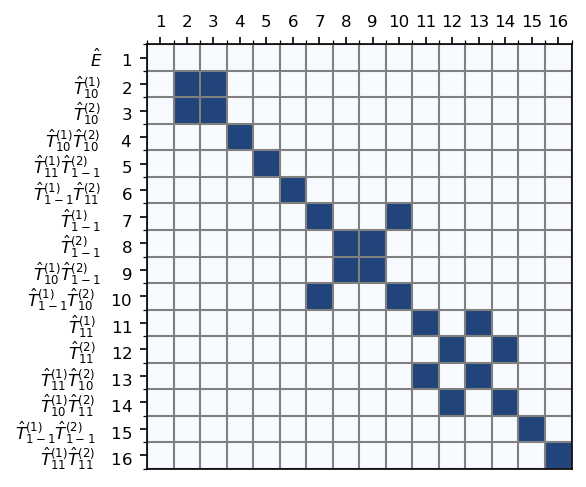

In [8]:
display(L.op)
L.visualize(basis_symbols=L.basis_symbols)

The same spin pair now carries the dipolar interaction twice over: its average as a coherent coupling, and its fluctuation as relaxation. The coherent coupling element `L.H.frequency` is shown first, then the relaxation rate `L.R.rate`.

In [9]:
display(L.H.frequency('111', '111*210'))
display(L.R.rate('111'))

2*pi*D_{12} + 2*pi*J_{12}

J^{DD12}_{20}(0)/12 + J^{DD12}_{20}(\omega_{13C})/8 + J^{DD12}_{20}(\omega_{1H})/16 + J^{DD12}_{20}(\omega_{13C} - \omega_{1H})/48 + J^{DD12}_{20}(\omega_{13C} + \omega_{1H})/8

The residual quadrupolar coupling is the single-spin counterpart, defined by a list of flags as the Zeeman interaction is. Here for a ²H nucleus, alongside the quadrupolar relaxation mechanism.

In [10]:
spin_system_Q = ['2D']

coh_intrs_Q = {'Z':   [1],
               'RQC': [1]}

incoh_intrs_Q = {'Q': ('1Q', [1], [2])}

L_Q = liouvillian_superoperator(spin_system_Q, coh_intrs_Q, incoh_intrs_Q)

################################################################################
                         Hamiltonian superoperator (H)                          
################################################################################

Computing H for the coherent interactions...
H computed in 0.00 seconds.

Changing basis...
Basis changed in 0.01 seconds.

Final clean-ups...
Done in 0.02 seconds.

################################################################################
                          Relaxation superoperator (R)                          
################################################################################

Computing R for incoherent interaction pairs...
  Q1 * Q1
R computed in 0.02 seconds.

Changing basis...
Basis changed in 0.03 seconds.

Final clean-ups...
Done in 0.05 seconds.



Display $L$ and visualize.

Matrix([
[0,                             0,                                                          0,                                                                                              0,                                                                                                0,                                                                                               0,                                                                                                 0,                                                                         0,                                                                          0],
[0, -3*J^{Q1}_{20}(\omega_{2D})/2,                                                          0,                                                                                              0,                                                                                                0,                                                                  

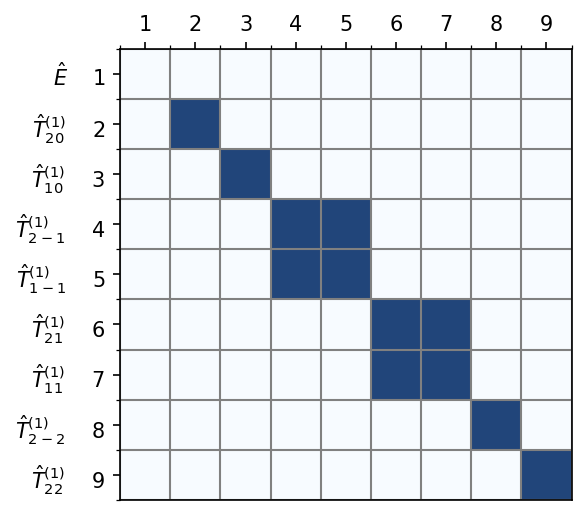

In [11]:
display(L_Q.op)
L_Q.visualize(basis_symbols=L_Q.basis_symbols)

The residual quadrupolar coupling connects operators of equal coherence order but different rank, which is what splits the spectrum. The coherent frequencies of the single-quantum operators are $\pm\omega_\mathrm{2D} \pm \omega_Q/2$, a doublet split by $\omega_Q$.

In [12]:
eigenvals = L_Q.H.op.eigenvals()
for val in eigenvals:
    display(val)

0

-\omega_{2D} + \omega_{Q}^{(1)}/2

-\omega_{2D} - \omega_{Q}^{(1)}/2

\omega_{2D} - \omega_{Q}^{(1)}/2

\omega_{2D} + \omega_{Q}^{(1)}/2

-2*\omega_{2D}

2*\omega_{2D}